In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


In [111]:
DATA_PATH="../data/raw/WA_fn-UseC_-Telco-Customer-Churn.csv"

In [112]:
df=pd.read_csv(DATA_PATH)

In [113]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [114]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [115]:
df['TotalCharges'].dtype

dtype('float64')

In [116]:
X=df.drop(columns=['customerID','Churn'])
y=df['Churn'].map({"No":0,"Yes":1})

In [117]:
numeric_features=X.select_dtypes(include=['int64','float64']).columns

categorical_features=X.select_dtypes(include=['str']).columns

In [118]:
numeric_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [119]:
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [120]:
print("Numerical Features: ")
print(numeric_features.tolist())
print("\nCategorical Features: ")
print(categorical_features.tolist())

Numerical Features: 
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features: 
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [121]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [122]:
print("Training distribution: ")
print(y_train.value_counts(normalize=True))
print("\nTesting distribution: ")
print(y_test.value_counts(normalize=True))

Training distribution: 
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing distribution: 
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [123]:
numeric_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())
])

In [124]:
categorical_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])

In [125]:
preprocessor=ColumnTransformer([
    ("num",numeric_pipeline,numeric_features),
    ("cat",categorical_pipeline,categorical_features)
])

In [126]:
logistic_model=LogisticRegression(max_iter=1000)

In [127]:
baseline_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",logistic_model)
])

In [128]:
baseline_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [129]:
y_pred=baseline_pipeline.predict(X_test)

In [130]:
baseline_pipeline.predict_proba(X_test)[:5]

array([[0.95470613, 0.04529387],
       [0.31558874, 0.68441126],
       [0.94127926, 0.05872074],
       [0.59829576, 0.40170424],
       [0.97845228, 0.02154772]])

In [131]:
y_prob=baseline_pipeline.predict_proba(X_test)[:,1]

In [132]:
prediction_results=pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred,
    "Churn_Probability":y_prob
})

In [133]:
prediction_results.head(10)

,Actual,Predicted,Churn_Probability
0,0,0,0.045294
1,0,1,0.684411
2,0,0,0.058721
3,0,0,0.401704
4,0,0,0.021548
5,0,1,0.603935
6,0,0,0.449225
7,0,0,0.130055
8,0,0,0.002881
9,1,0,0.395179


In [134]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy: ",accuracy)

Accuracy:  0.8055358410220014


In [135]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[926, 109],
       [165, 209]])

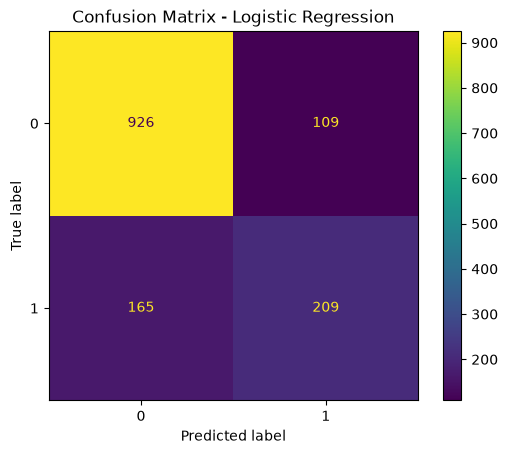

In [136]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()



In [137]:
precision=precision_score(y_test,y_pred)
precision

0.6572327044025157

In [138]:
recall=recall_score(y_test,y_pred)
recall

0.5588235294117647

In [139]:
f1=f1_score(y_test,y_pred)

print("F1 Score: ",f1)

F1 Score:  0.6040462427745664


In [140]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040


In [141]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [142]:
roc_auc=roc_auc_score(y_test,y_prob)

print("ROC-AUC : ",roc_auc)

ROC-AUC :  0.8418610659019866


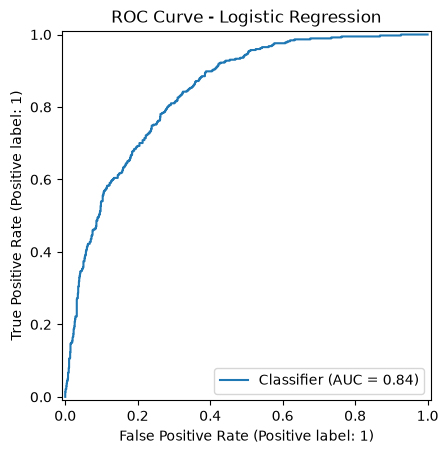

In [143]:
RocCurveDisplay.from_predictions(y_test,y_prob)

plt.title('ROC Curve - Logistic Regression')
plt.show()

In [144]:
baseline_results=pd.DataFrame({
    "Model":["Logistic Regression"],
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "ROC_AUC":roc_auc
})

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861


In [145]:
random_forest_model=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [146]:
random_forest_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",random_forest_model)
])

In [147]:
random_forest_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [148]:
rf_y_pred=random_forest_pipeline.predict(X_test)

In [149]:
rf_y_prob=random_forest_pipeline.predict_proba(X_test)[:,1]

In [150]:
rf_accuracy=accuracy_score(y_test,rf_y_pred)
rf_accuracy

0.7757274662881476

In [151]:
rf_precision=precision_score(y_test,rf_y_pred)
rf_precision

0.6

In [152]:
rf_recall=recall_score(y_test,rf_y_pred)
rf_recall

0.46524064171123

In [153]:
rf_f1=f1_score(y_test,rf_y_pred)
rf_f1

0.5240963855421686

In [154]:
rf_roc_auc=roc_auc_score(y_test,rf_y_pred)
rf_roc_auc

0.6765816735126198

In [155]:
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Accuracy : 0.7757
Precision: 0.6000
Recall   : 0.4652
F1 Score : 0.5241
ROC-AUC  : 0.6766


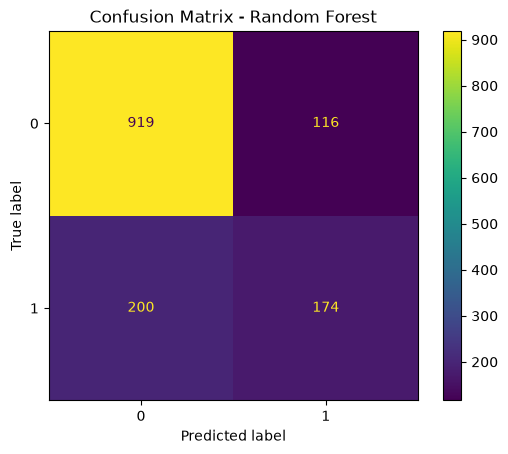

In [156]:
ConfusionMatrixDisplay.from_predictions(y_test,rf_y_pred)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [157]:
print(
    classification_report(
        y_test,
        rf_y_pred,
        target_names=["No Churn","Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.47      0.52       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



In [158]:
rf_results=pd.DataFrame({
    "Model":["Random Forest"],
    "Accuracy":[rf_accuracy],
    "Precision":[rf_precision],
    "Recall":[rf_recall],
    "F1":[rf_f1],
    "ROC_AUC":[rf_roc_auc]
})

In [159]:
rf_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.775727,0.6,0.465241,0.524096,0.676582


In [160]:
model_comparison=pd.concat([
    baseline_results,
    rf_results
],ignore_index=True
)

In [161]:
model_comparison.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582


In [162]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582


In [163]:
from xgboost import XGBClassifier

In [164]:
xgb_model=XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [165]:
xgb_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",xgb_model)
])

In [166]:
xgb_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [167]:
xgb_y_pred=xgb_pipeline.predict(X_test)


In [168]:
xgb_y_prob=xgb_pipeline.predict_proba(X_test)[:,1]

In [169]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_y_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_y_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_y_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_y_pred
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_y_prob
)

In [170]:
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

Accuracy : 0.8070
Precision: 0.6735
Recall   : 0.5294
F1 Score : 0.5928
ROC-AUC  : 0.8444


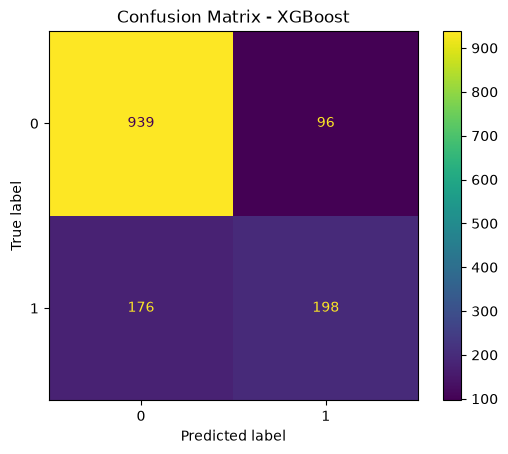

In [171]:
ConfusionMatrixDisplay.from_predictions(y_test,xgb_y_pred)

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [172]:
print(
    classification_report(
            y_test,
            xgb_y_pred,
            target_names=["No Churn","Churn"]
        )

    )

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



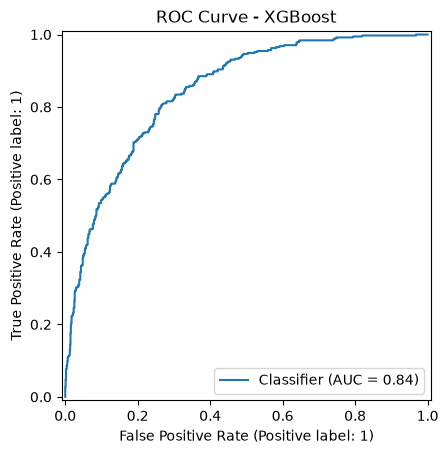

In [173]:
RocCurveDisplay.from_predictions(y_test,xgb_y_prob)

plt.title("ROC Curve - XGBoost")
plt.show()

In [174]:
xgb_results=pd.DataFrame({
    "Model":["XGBoost"],
    "Accuracy":[xgb_accuracy],
    "Precision":[xgb_precision],
    "Recall":[xgb_recall],
    "F1":[xgb_f1],
    "ROC_AUC":[xgb_roc_auc]
    })

In [175]:
xgb_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371


In [176]:
model_comparison=pd.concat([
    baseline_results,
    rf_results,
    xgb_results
],ignore_index=True)

In [177]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582
2,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371


In [178]:
model_comparison.sort_values(by="ROC_AUC",ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582


In [181]:
param_distributions={
    "model__n_estimators" : [100,200,300,400],
    "model__learning_rate":[0.01,0.03,0.05,0.1],
    "model__max_depth":[3,4,5,6],
    "model__min_child_weight":[1,3,5],
    "model__subsample" : [0.7,0.8,1.0],
    "model__colsample_bytree":[0.7,0.8,1.0]
}

In [182]:
from sklearn.model_selection import RandomizedSearchCV

In [183]:
random_search=RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [184]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best

In [185]:
random_search.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 100,
 'model__min_child_weight': 5,
 'model__max_depth': 3,
 'model__learning_rate': 0.05,
 'model__colsample_bytree': 0.7}

In [186]:
random_search.best_score_

np.float64(0.8496689717525727)

In [187]:
best_xgb_pipeline=random_search.best_estimator_

In [188]:
tuned_y_pred=best_xgb_pipeline.predict(X_test)

In [189]:
tuned_y_prob=best_xgb_pipeline.predict_proba(X_test)[:,1]

In [190]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_y_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_y_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_y_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_y_pred
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_y_prob
)

In [191]:
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1       : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

Accuracy : 0.8098
Precision: 0.6815
Recall   : 0.5321
F1       : 0.5976
ROC-AUC  : 0.8481


In [192]:
tuned_results=pd.DataFrame({
    "Model":["Tuned XGBoost"],
    "Accuracy":[tuned_accuracy],
    "Precision":[tuned_precision],
    "Recall":[tuned_recall],
    "F1":[tuned_f1],
    "ROC_AUC":[tuned_roc_auc]
})

In [193]:
model_comparison=pd.concat([
    baseline_results,
    rf_results,
    xgb_results,
    tuned_results
],ignore_index=True)

In [194]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582
2,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371
3,Tuned XGBoost,0.809794,0.681507,0.532086,0.597598,0.848051


In [195]:
model_comparison.sort_values(by='ROC_AUC',ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Tuned XGBoost,0.809794,0.681507,0.532086,0.597598,0.848051
2,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582


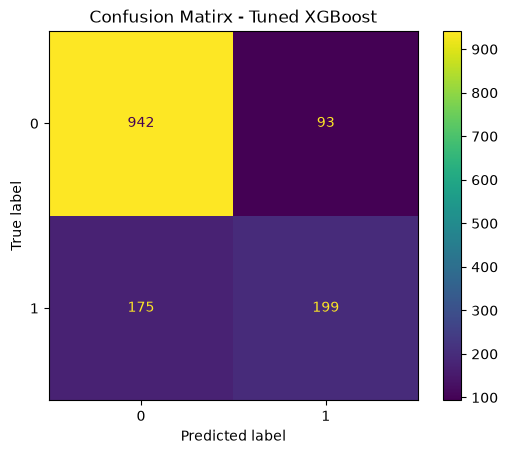

In [197]:
ConfusionMatrixDisplay.from_predictions(y_test,tuned_y_pred)

plt.title("Confusion Matirx - Tuned XGBoost")
plt.show()

In [199]:
print(
    classification_report(
        y_test,
        tuned_y_pred,
        target_names=["No Churn","Churn"]

    )

)

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.88      1035
       Churn       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [200]:
threshold=0.40

custom_y_pred=(tuned_y_prob>=threshold).astype(int)

In [201]:
custom_accuracy = accuracy_score(
    y_test,
    custom_y_pred
)

custom_precision = precision_score(
    y_test,
    custom_y_pred
)

custom_recall = recall_score(
    y_test,
    custom_y_pred
)

custom_f1 = f1_score(
    y_test,
    custom_y_pred
)

print(f"Threshold : {threshold}")
print(f"Accuracy  : {custom_accuracy:.4f}")
print(f"Precision : {custom_precision:.4f}")
print(f"Recall    : {custom_recall:.4f}")
print(f"F1        : {custom_f1:.4f}")

Threshold : 0.4
Accuracy  : 0.7899
Precision : 0.5938
Recall    : 0.6604
F1        : 0.6253


In [212]:
thresholds = [
    0.20, 0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.55, 0.60, 0.65, 0.70
]

threshold_results = []

for threshold in thresholds:

    custom_pred = (
        tuned_y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            custom_pred
        ),

        "Precision": precision_score(
            y_test,
            custom_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            custom_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            custom_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.706884,0.471111,0.850267,0.606292
1,0.25,0.738112,0.504160,0.810160,0.621538
2,0.30,0.757275,0.528881,0.783422,0.631466
3,0.35,0.778566,0.564050,0.729947,0.636364
4,0.40,0.789922,0.593750,0.660428,0.625316
5,0.45,0.797729,0.625352,0.593583,0.609053
6,0.50,0.809794,0.681507,0.532086,0.597598
7,0.55,0.804826,0.723982,0.427807,0.537815
8,0.60,0.794890,0.757576,0.334225,0.463822
9,0.65,0.787793,0.786260,0.275401,0.407921


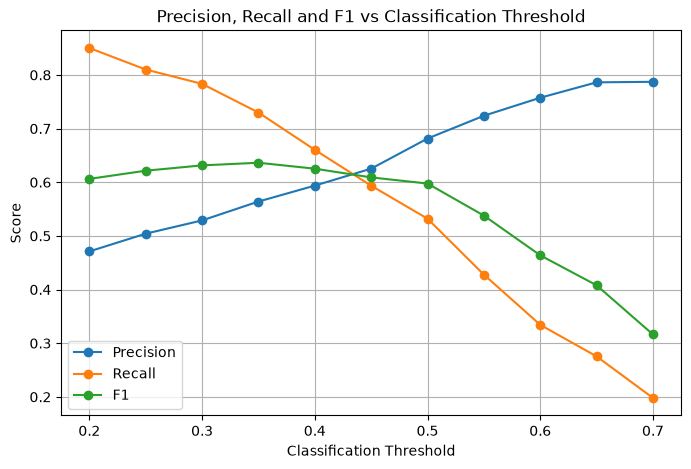

In [213]:
plt.figure(figsize=(8,5))

plt.plot(threshold_df["Threshold"],threshold_df["Precision"],marker='o',label="Precision"),

plt.plot(threshold_df["Threshold"],threshold_df["Recall"],marker="o",label="Recall"),

plt.plot(threshold_df["Threshold"],threshold_df["F1"],marker="o",label="F1")


plt.xlabel("Classification Threshold")

plt.ylabel("Score")

plt.title("Precision, Recall and F1 vs Classification Threshold")

plt.legend()

plt.grid()
plt.show()

In [214]:
from sklearn.metrics import precision_recall_curve

In [215]:
precision,recall,thresholds=precision_recall_curve(y_test,tuned_y_prob)

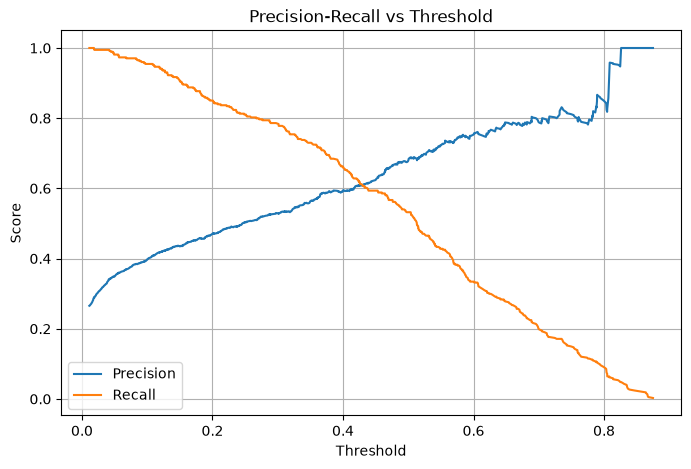

In [217]:
plt.figure(figsize=(8,5))

plt.plot(thresholds,precision[:-1],label="Precision")

plt.plot(thresholds,recall[:-1],label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [218]:
f1_scores=(2*precision[:-1]*recall[:-1]/(precision[:-1]+recall[:-1]+1e-10))


best_index=np.argmax(f1_scores)

best_threshold=thresholds[best_index]
best_f1=f1_scores[best_index]

print("Best Threshold: ",best_threshold)
print("Best F1: ",best_f1)

Best Threshold:  0.3666335
Best F1:  0.6433734939263916


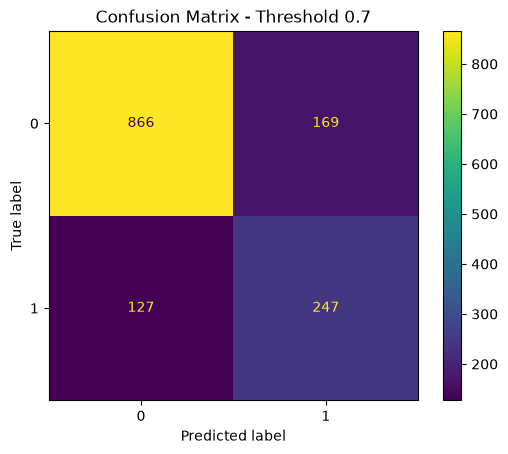

In [219]:
ConfusionMatrixDisplay.from_predictions(y_test,custom_y_pred)

plt.title(f"Confusion Matrix - Threshold {threshold}")
plt.show()
